# Module 02 — Bring your own dynamics

The 154 built-in systems are a playground, but your research lives in the equations
*you* write down. In this module you learn the one contract that lets `tsdynamics`
turn a symbolic right-hand side into a fully-featured system — integrable on the Rust
engine, differentiable (autogenerated Jacobian), analysable by every tool in the
library, and automatically registered. Get this contract right once and everything
downstream — Lyapunov spectra, fixed points, basins — *just works* on your model.

**You will learn to:**
- Subclass `ts.ContinuousSystem` with the correct `_equations` contract (staticmethod,
  keyword-only params, `symengine`).
- Declare the required metadata (`dim`, `params`, `variables`, `default_ic`).
- Recognise and avoid the three classic failure modes (missing `dim`, non-staticmethod
  `_equations`, using `numpy` instead of `symengine`).
- Let the library autogenerate the Jacobian and confirm it symbolically.
- Build a custom **map** (`ts.DiscreteMap`) and a custom **SDE** (`ts.StochasticSystem`).
- See your class auto-register and immediately feed the analysis toolkit.

*Estimated time: 30 min.*

In [1]:
# Colab/first-run setup: install the workshop stack if tsdynamics is missing.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "pandas"], check=True)
# Render figures inline. traj.plot() returns a matplotlib Figure, so end a plot cell
# with `fig` as the last expression and the inline backend embeds it.
get_ipython().run_line_magic("matplotlib", "inline")  # noqa: F821
import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts
print("tsdynamics", ts.__version__)

tsdynamics 5.3.1


## 1. The contract, in one class

A continuous system is defined by its vector field $\dot{\mathbf{y}} = \mathbf{f}(\mathbf{y}, t)$.
You give `tsdynamics` that field *symbolically* — as `symengine` expressions — and it
lowers them to an intermediate-representation "tape" that the Rust engine integrates.
There is **no compile step and no warmup**: edit an equation, re-run, done.

Let's build the **Van der Pol oscillator**, the canonical self-sustained relaxation
oscillator (van der Pol, 1926), which is *not* in the catalogue:

$$\dot x = v, \qquad \dot v = \mu\,(1 - x^2)\,v - x.$$

Read the class below carefully — every line is part of the contract:

- `params` — a dict of **control parameters** (read live on every run, never baked into
  the tape, so you can sweep them cheaply).
- `dim` — the state dimension. **REQUIRED.** It is *not* inferred from `default_ic`.
- `variables` — optional component names; declaring them enables `traj["x"]`.
- `default_ic` — a fallback initial condition.
- `_equations` — a **`@staticmethod`** with signature `(y, t, *, **params)`: state is
  read positionally via `y(0), y(1), …`, parameters arrive **keyword-only**, and it
  returns a list/tuple of RHS expressions built from `symengine` (`se.sin`, `se.exp`, …).

In [2]:
import symengine as se


class VanDerPol(ts.ContinuousSystem):
    """Van der Pol relaxation oscillator (van der Pol, 1926)."""

    params = {"mu": 1.5}                 # control parameter(s), read live
    dim = 2                              # REQUIRED — state dimension
    variables = ("x", "v")              # enables traj["x"], traj["v"]
    default_ic = [0.1, 0.0]             # fallback initial condition
    reference = "van der Pol, Phil. Mag. (1926)"

    @staticmethod                        # REQUIRED: _equations is a staticmethod ...
    def _equations(y, t, *, mu):         # ... with keyword-only parameters (y, t, *, **p)
        x, v = y(0), y(1)                # state via y(0), y(1), ...
        return [v, mu * (1.0 - x * x) * v - x]   # list of RHS expressions


vdp = VanDerPol()
traj = vdp.integrate(final_time=40.0, dt=0.01)
print("state shape :", traj.y.shape)     # (n_steps, dim)
print("params      :", traj.meta["params"])
traj["x"][:3]                            # named-component access works

state shape : (4001, 2)
params      : {'mu': 1.5}


array([0.1       , 0.09999498, 0.0999798 ])

That's a complete, first-class system. It integrated on the default `interp` backend,
and because we declared `variables`, `traj["x"]` resolves by name. Let's look at the
limit cycle — the hallmark of the Van der Pol oscillator is a closed orbit that any
initial condition spirals onto.

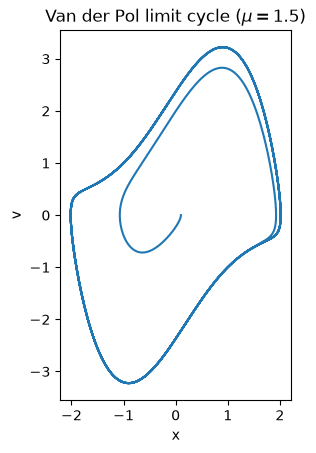

In [3]:
fig = traj.plot(kind="phase_portrait_2d", components=["x", "v"])
fig.axes[0].set_title(r"Van der Pol limit cycle ($\mu=1.5$)")
fig

The trajectory settles onto a single closed loop — a stable limit cycle. Increase `mu`
and the orbit becomes more "relaxation-like" (fast jumps + slow crawls). Because `params`
is read live, you can re-parametrise without redefining the class: `vdp.with_params(mu=4.0)`.

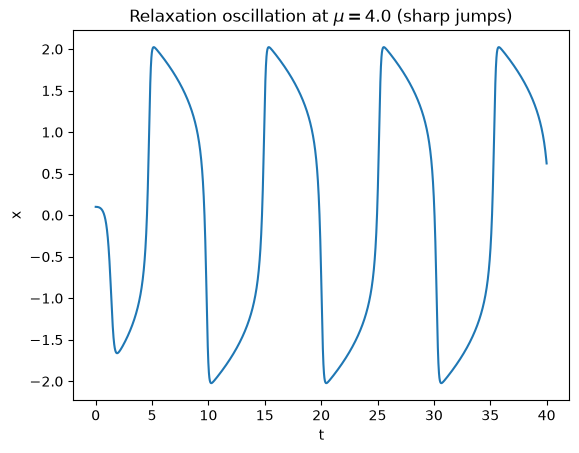

In [4]:
vdp_stiff = vdp.with_params(mu=4.0)
traj4 = vdp_stiff.integrate(final_time=40.0, dt=0.01)
fig = traj4.plot(kind="time_series", components=["x"])
fig.axes[0].set_title(r"Relaxation oscillation at $\mu=4.0$ (sharp jumps)")
fig

## 2. The Jacobian is free — you never hand-write it

Many analyses (stability, stiff solvers, Lyapunov exponents, `fixed_points`) need the
Jacobian $J_{ij} = \partial f_i / \partial y_j$. You do **not** supply it: `tsdynamics`
differentiates your symbolic `_equations` with `symengine` and caches a fast numeric
evaluator. `jacobian_sym()` returns the symbolic matrix; `jacobian(u, t)` evaluates it.

In [5]:
print("Symbolic Jacobian:")
for row in vdp.jacobian_sym():
    print("   ", row)

u = np.array([0.5, 0.3])
print("\nNumeric J at u =", u, ", t = 0:")
print(vdp.jacobian(u, 0.0))

Symbolic Jacobian:
    [0, 1]
    [-1 - 2*mu*y(0)*y(1), mu*(1.0 - y(0)**2)]

Numeric J at u = [0.5 0.3] , t = 0:
[[ 0.     1.   ]
 [-1.45   1.125]]


For Van der Pol the exact Jacobian is
$\begin{pmatrix} 0 & 1 \\ -2\mu x v - 1 & \mu(1 - x^2)\end{pmatrix}$ — which is exactly
what `jacobian_sym()` prints. This is the machinery that makes the *next* module's
stability analysis and the stiff `bdf` solver possible without any extra work from you.

## 3. The three failure modes (name them, avoid them)

This is where people trip. Each of the following is a real, reproducible mistake — we
trigger them on purpose so you recognise the error message in the wild. **None of these
are library bugs; they are contract violations.**

**(a) Forgetting `dim`.** `dim` is a required ClassVar. Omit it and lowering tries
`int(None)` and fails with a cryptic `TypeError`:

In [6]:
try:
    class NoDim(ts.ContinuousSystem):
        params = {"mu": 1.0}
        default_ic = [0.1, 0.0]          # <-- dim is NOT inferred from this!
        @staticmethod
        def _equations(y, t, *, mu):
            return [y(1), mu * (1 - y(0) ** 2) * y(1) - y(0)]

    NoDim().integrate(final_time=1.0, dt=0.01)
except TypeError as exc:
    print("FAILURE (a) — missing dim:")
    print("   ", exc)

FAILURE (a) — missing dim:
    int() argument must be a string, a bytes-like object or a real number, not 'NoneType'


**(b) A non-`staticmethod` `_equations`.** Write `def _equations(self, y, t, *, mu)`
and integration may *appear* to work, but tools that call the RHS **unbound** —
`fixed_points`, the Jacobian autogen — invoke `type(self)._equations(y, t, **params)`
with no `self`, so the arguments shift and it crashes. Always use `@staticmethod`.

In [7]:
from tsdynamics.data import Box

try:
    class BadVdP(ts.ContinuousSystem):
        params = {"mu": 1.5}
        dim = 2
        default_ic = [0.1, 0.0]
        def _equations(self, y, t, *, mu):   # WRONG: 'self' makes it a bound method
            return [y(1), mu * (1 - y(0) ** 2) * y(1) - y(0)]

    bad = BadVdP()
    ts.fixed_points(bad, region=Box(np.array([-3.0, -3.0]), np.array([3.0, 3.0])), n_seeds=20)
except TypeError as exc:
    print("FAILURE (b) — non-staticmethod _equations breaks fixed_points:")
    print("   ", exc)

FAILURE (b) — non-staticmethod _equations breaks fixed_points:
    BadVdP._equations() missing 1 required positional argument: 't'


**(c) Using `numpy` / `math` instead of `symengine`.** The RHS is *symbolic* — it is
differentiated and lowered to the engine tape, so it must be built from `symengine`
functions (`se.sin`, `se.cos`, `se.exp`, `se.sqrt`, …), never `np.sin` or `math.sin`.
A `numpy` call receives a symbolic node it cannot evaluate and raises. The fix is
simply `import symengine as se` and use `se.sin(x)`.

```python
# WRONG — numpy cannot operate on a symbolic state node:
def _equations(y, t, *, a):
    return [np.sin(y(0)), -a * y(1)]     # TypeError deep inside numpy

# RIGHT:
def _equations(y, t, *, a):
    return [se.sin(y(0)), -a * y(1)]
```

**Rule of thumb:** staticmethod, `dim=`, `symengine`. Three things — commit them to muscle memory.

## 4. Your class auto-registers

Defining a concrete subclass registers it automatically (as a *non-builtin* entry) — no
manual step. That means it shows up in the registry alongside the 154 built-ins and is
swept by the same analysis machinery.

In [8]:
from tsdynamics import registry

user_systems = list(registry.all_systems(builtin=False))
print("User-defined systems registered this session:")
for entry in user_systems:
    print(f"   {entry.name:14s} family={entry.family}  dim={entry.dim}  params={list(entry.params)}")

User-defined systems registered this session:
   VanDerPol      family=ode  dim=2  params=['mu']
   NoDim          family=ode  dim=None  params=['mu']
   BadVdP         family=ode  dim=2  params=['mu']


## 5. A custom map

Discrete-time maps subclass `ts.DiscreteMap`. The contract differs from ODEs in one
important way: `_step` receives the **whole state vector `X`** (a length-`dim` array)
followed by the parameters *positionally, in `params`-dict order* — and it returns the
next state as a tuple. If your `_step` argument order disagrees with the `params` dict,
the class **raises at import time** (a deliberate guard against silently swapped values).

Here is a custom quadratic map (a Hénon-style fold):

$$x_{n+1} = 1 - a\,x_n^2 + y_n, \qquad y_{n+1} = b\,x_n.$$

largest Lyapunov exponent: 0.4150074053061281


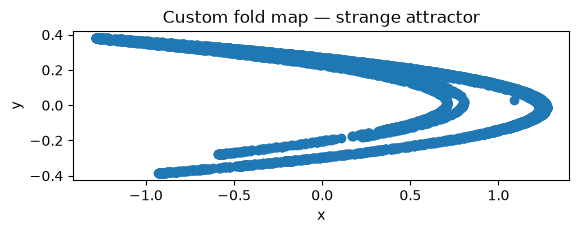

In [9]:
class FoldMap(ts.DiscreteMap):
    """A custom Hénon-style quadratic fold."""

    params = {"a": 1.4, "b": 0.3}        # order here MUST match _step's arg order
    dim = 2
    variables = ("x", "y")
    default_ic = [0.1, 0.1]

    @staticmethod
    def _step(X, a, b):                  # X is the full state vector; then params in order
        x, y = X[0], X[1]
        return (1.0 - a * x * x + y, b * x)


fm = FoldMap()
mt = fm.iterate(steps=4000)
print("largest Lyapunov exponent:", ts.max_lyapunov(fm, ic=[0.1, 0.1]).value)
fig = mt.plot(kind="phase_portrait_2d", components=["x", "y"])
fig.axes[0].set_title("Custom fold map — strange attractor")
fig

A positive largest Lyapunov exponent (~0.4) confirms the attractor is chaotic. Note we
ran `max_lyapunov` on our *own* map with zero extra plumbing — registration + the
uniform protocol did all the work. (You may optionally add a `@staticmethod _jacobian(X, *params)`
returning the analytic Jacobian rows; for maps that lower cleanly, the engine derives
it from `_step` automatically.)

## 6. A custom SDE

Stochastic systems subclass `ts.StochasticSystem` and split the dynamics into a
deterministic **drift** and a per-component **diffusion** (a diagonal-Itô SDE
$dX_k = f_k\,dt + g_k\,dW_k$ with independent Wiener increments). Both are symbolic,
both keyword-only, same `y(0), y(1), …` state accessor as an ODE. A component with *no*
noise gets a symbolic zero — write it as `se.Integer(0) * y(0)` so the tape stays a
valid symbolic expression.

Here is a linear oscillator kicked by noise on the velocity only:

$$dx = v\,dt, \qquad dv = -\omega^2 x\,dt + \sigma\,dW.$$

seed 1 reproduces itself : True
seed 1 differs from seed 7: True


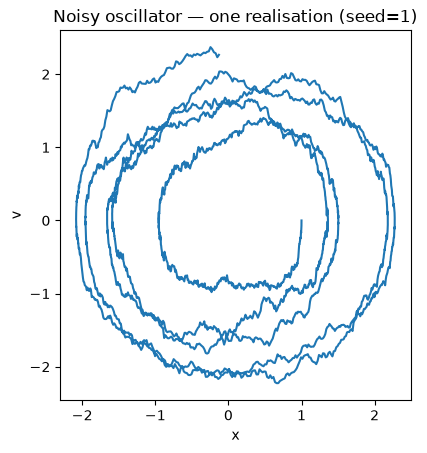

In [10]:
class NoisyOscillator(ts.StochasticSystem):
    """Harmonic oscillator with additive velocity noise."""

    params = {"omega": 1.0, "sigma": 0.3}
    dim = 2
    variables = ("x", "v")
    default_ic = [1.0, 0.0]

    @staticmethod
    def _drift(y, t, *, omega, sigma):
        x, v = y(0), y(1)
        return [v, -omega * omega * x]

    @staticmethod
    def _diffusion(y, t, *, omega, sigma):
        return [se.Integer(0) * y(0), sigma]   # no noise on x; additive noise on v


osc = NoisyOscillator()
tr_a = osc.integrate(final_time=30.0, dt=0.01, seed=1)
tr_b = osc.integrate(final_time=30.0, dt=0.01, seed=1)   # same seed → identical
tr_c = osc.integrate(final_time=30.0, dt=0.01, seed=7)   # different seed → different path
print("seed 1 reproduces itself :", np.allclose(tr_a.y, tr_b.y))
print("seed 1 differs from seed 7:", not np.allclose(tr_a.y, tr_c.y))

fig = tr_a.plot(kind="phase_portrait_2d", components=["x", "v"])
fig.axes[0].set_title("Noisy oscillator — one realisation (seed=1)")
fig

The noise smears the deterministic ellipse into a diffusing cloud. A fixed `seed` makes
the realisation reproducible (essential for debugging and figures); `dt` sets *both* the
time grid and the noise scale $\sqrt{dt}$. `ensemble(...)` fans many seeded realisations
out in parallel — the tool of choice for stationary distributions and escape statistics
(we'll lean on that in **Module 07**).

## 7. Payoff: a custom system feeds the whole toolkit

The point of getting the contract right is that your model is now indistinguishable from
a built-in. Let's define **FitzHugh–Nagumo** (a two-variable neuron model, not in the
catalogue) and immediately extract its fixed point *and* the eigenvalues that classify
its stability — a preview of **Module 06**.

$$\dot v = v - \tfrac{v^3}{3} - w + I, \qquad \dot w = \varepsilon\,(v + a - b\,w).$$

In [11]:
class FitzHughNagumo(ts.ContinuousSystem):
    """FitzHugh–Nagumo excitable neuron (FitzHugh 1961; Nagumo et al. 1962)."""

    params = {"a": 0.7, "b": 0.8, "eps": 0.08, "I": 0.5}
    dim = 2
    variables = ("v", "w")
    default_ic = [-1.0, -0.5]

    @staticmethod
    def _equations(y, t, *, a, b, eps, I):
        v, w = y(0), y(1)
        return [v - v * v * v / 3.0 - w + I, eps * (v + a - b * w)]


fhn = FitzHughNagumo()
fps = ts.fixed_points(fhn, region=Box(np.array([-3.0, -3.0]), np.array([3.0, 3.0])), n_seeds=100)
print(f"found {len(fps)} fixed point(s)")
for fp in fps:
    kind = "stable" if fp.stable else "UNSTABLE"
    print(f"   x = {np.round(fp.x, 4)}   {kind}   eigenvalues = {np.round(fp.eigenvalues, 4)}")

found 1 fixed point(s)
   x = [-0.8048 -0.1311]   UNSTABLE   eigenvalues = [0.1441+0.1915j 0.1441-0.1915j]


With $I = 0.5$ the single fixed point is an **unstable spiral** (a complex-conjugate pair
with positive real part) — the system has crossed a Hopf bifurcation and sustains a limit
cycle (tonic firing). Let's confirm by overlaying the trajectory and the fixed point.

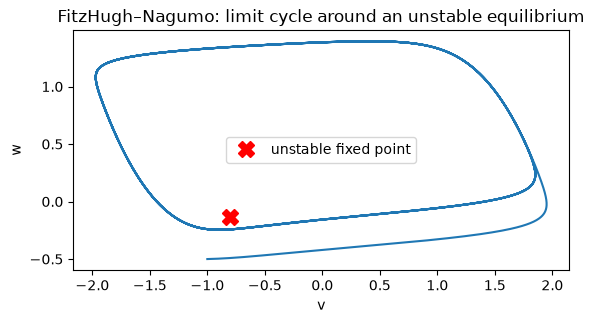

In [12]:
tr = fhn.integrate(final_time=200.0, dt=0.02)
fig = tr.plot(kind="phase_portrait_2d", components=["v", "w"])
ax = fig.axes[0]
for fp in fps:
    ax.plot(fp.x[0], fp.x[1], "rX", markersize=12, label="unstable fixed point")
ax.legend()
ax.set_title("FitzHugh–Nagumo: limit cycle around an unstable equilibrium")
fig

The orbit encircles the equilibrium exactly as the eigenvalues predicted. Every tool you
meet in the rest of the workshop — Lyapunov spectra, basins, tipping points — will accept
a system you built the same way. In the **capstone ("Guardian of the Grid")** you will
define a power-grid node model with this very pattern and probe its stability.

## 🧪 Exercises

Fill in each starter cell (look for `# YOUR CODE HERE`). Worked answers are in the
**Solutions** section at the end — try first!

**Exercise 1 — Implement the Brusselator.**
The Brusselator is a two-species autocatalytic reaction model:

$$\dot x = a + x^2 y - (b+1)\,x, \qquad \dot y = b\,x - x^2 y.$$

Implement it as a `ts.ContinuousSystem` (params `a=1.0, b=3.0`, `dim=2`,
`variables=("x","y")`, `default_ic=[1.0, 1.0]`), integrate for `final_time=40, dt=0.01`,
and plot the phase portrait. You should see a stable limit cycle (because $b > 1 + a^2$).
*Hint: mirror the `VanDerPol` class exactly — staticmethod, keyword-only params.*

In [13]:
# Exercise 1 — your Brusselator
class Brusselator(ts.ContinuousSystem):
    pass  # YOUR CODE HERE


# YOUR CODE HERE: instantiate, integrate (final_time=40, dt=0.01), and plot the 2-D phase portrait

**Exercise 2 — Add named components and read one.**
Take your Brusselator trajectory from Exercise 1. Use the `variables` you declared to
pull out the `x` component *by name* (not by index), and plot it as a time series.
*Hint: `traj["x"]` works because you declared `variables=("x","y")`; the plot kind is `"time_series"`.*

In [14]:
# Exercise 2 — named-component access + time series
# YOUR CODE HERE

**Exercise 3 — Build a custom map.**
Implement the **Tinkerbell-style** quadratic map

$$x_{n+1} = x_n^2 - y_n^2 + a\,x_n + b\,y_n, \qquad y_{n+1} = 2 x_n y_n + c\,x_n + d\,y_n,$$

as a `ts.DiscreteMap` with params `{"a": 0.9, "b": -0.6013, "c": 2.0, "d": 0.5}`,
`dim=2`, `default_ic=[-0.72, -0.64]`. Iterate for 6000 steps and plot the attractor.
*Hint: `_step(X, a, b, c, d)` — the whole state vector `X` first, then params in dict order.
Watch the param ORDER: it must match `_step`'s signature or the class raises at import.*

In [15]:
# Exercise 3 — custom map
class TinkerMap(ts.DiscreteMap):
    pass  # YOUR CODE HERE


# YOUR CODE HERE: iterate 6000 steps and plot the 2-D phase portrait

**Exercise 4 — A 2-D custom system and its fixed points (stretch).**
Implement the **damped pendulum with constant torque**

$$\dot\theta = \omega, \qquad \dot\omega = -\gamma\,\omega - \sin\theta + \tau,$$

with params `{"gamma": 0.3, "tau": 0.5}`, `dim=2`, `variables=("theta","omega")`.
Use `se.sin` for the nonlinearity. Then call `ts.fixed_points` over a `Box` region and
print each equilibrium's location, stability, and eigenvalues.
*Hint: with $\tau = 0.5 < 1$ there is an equilibrium where $\sin\theta = \tau$; use a
region like `Box([-3, -3], [3, 3])`. Remember: staticmethod, or `fixed_points` breaks.*

In [16]:
# Exercise 4 — pendulum with torque + fixed points
class TorquedPendulum(ts.ContinuousSystem):
    pass  # YOUR CODE HERE


# YOUR CODE HERE: build a Box region, call ts.fixed_points, print x / stable / eigenvalues

## ✅ Solutions

### Solution 1

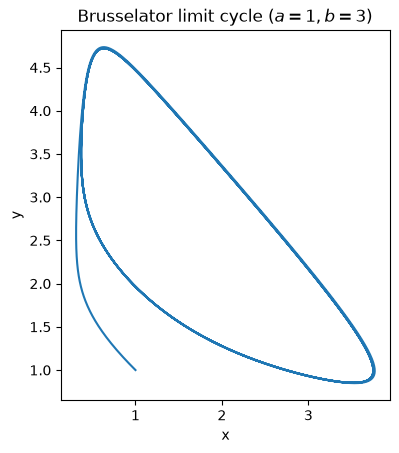

In [17]:
class Brusselator(ts.ContinuousSystem):
    """Brusselator autocatalytic reaction (Prigogine & Lefever, 1968)."""

    params = {"a": 1.0, "b": 3.0}
    dim = 2
    variables = ("x", "y")
    default_ic = [1.0, 1.0]

    @staticmethod
    def _equations(y, t, *, a, b):
        x, yy = y(0), y(1)
        return [a + x * x * yy - (b + 1.0) * x, b * x - x * x * yy]


brus = Brusselator()
tr1 = brus.integrate(final_time=40.0, dt=0.01)
fig = tr1.plot(kind="phase_portrait_2d", components=["x", "y"])
fig.axes[0].set_title(r"Brusselator limit cycle ($a=1, b=3$)")
fig

### Solution 2

x component shape: (4001,)


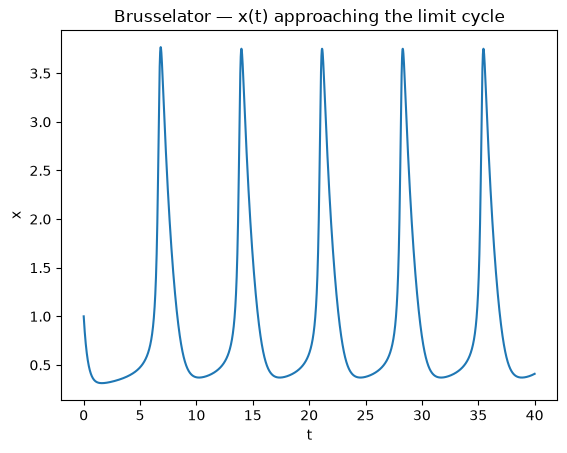

In [18]:
x_series = tr1["x"]                       # named access — enabled by variables=("x","y")
print("x component shape:", x_series.shape)
fig = tr1.plot(kind="time_series", components=["x"])
fig.axes[0].set_title("Brusselator — x(t) approaching the limit cycle")
fig

### Solution 3

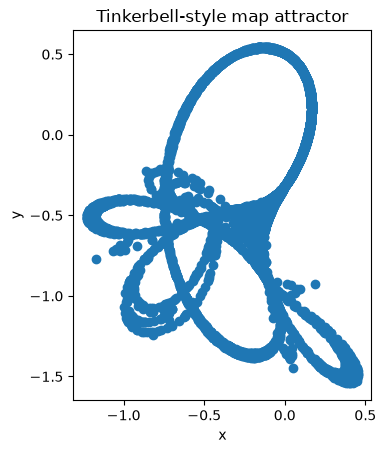

In [19]:
class TinkerMap(ts.DiscreteMap):
    """Tinkerbell-style quadratic map."""

    params = {"a": 0.9, "b": -0.6013, "c": 2.0, "d": 0.5}
    dim = 2
    variables = ("x", "y")
    default_ic = [-0.72, -0.64]

    @staticmethod
    def _step(X, a, b, c, d):             # state vector first, then params in dict order
        x, y = X[0], X[1]
        return (x * x - y * y + a * x + b * y, 2.0 * x * y + c * x + d * y)


tk = TinkerMap()
mt = tk.iterate(steps=6000)
fig = mt.plot(kind="phase_portrait_2d", components=["x", "y"])
fig.axes[0].set_title("Tinkerbell-style map attractor")
fig

### Solution 4

In [20]:
class TorquedPendulum(ts.ContinuousSystem):
    """Damped pendulum driven by a constant torque."""

    params = {"gamma": 0.3, "tau": 0.5}
    dim = 2
    variables = ("theta", "omega")
    default_ic = [0.0, 0.0]

    @staticmethod
    def _equations(y, t, *, gamma, tau):
        theta, omega = y(0), y(1)
        return [omega, -gamma * omega - se.sin(theta) + tau]


pend = TorquedPendulum()
fps = ts.fixed_points(
    pend, region=Box(np.array([-3.0, -3.0]), np.array([3.0, 3.0])), n_seeds=100
)
print(f"found {len(fps)} fixed point(s):")
for fp in fps:
    kind = "stable" if fp.stable else "unstable"
    print(f"   theta,omega = {np.round(fp.x, 4)}   {kind}   eig = {np.round(fp.eigenvalues, 4)}")

found 2 fixed point(s):
   theta,omega = [0.5236 0.    ]   stable   eig = [-0.15+0.9184j -0.15-0.9184j]
   theta,omega = [2.618 0.   ]   unstable   eig = [ 0.7926+0.j -1.0926+0.j]


With $\tau = 0.5 < 1$ the printout shows **two** equilibria (both at $\omega = 0$), the pair
$\sin\theta = \tau$ always comes in:

- **A stable spiral at $\theta = \arcsin(\tau) \approx 0.524$** — eigenvalues
  $-0.15 \pm 0.918i$, a complex-conjugate pair with negative real part. This is the
  resting tilt the pendulum spirals down to.
- **A saddle at $\theta = \pi - \arcsin(\tau) \approx 2.618$** — real eigenvalues of
  opposite sign ($+0.793$, $-1.093$), so it is *unstable*. Its stable manifold is the
  **separatrix** that divides the resting basin (orbits that fall into the spiral) from the
  **running** solutions (the pendulum whirls over the top and keeps spinning).

So even below $\tau = 1$ the system is genuinely bistable: whether it settles to a fixed
tilt or runs away depends on which side of the saddle's separatrix the initial condition
starts. Try `tau > 1` (the two equilibria merge and annihilate in a saddle-node — no rest
state, the pendulum always runs) or `gamma → 0` to feel the boundary.

## Recap / Where next

You now own the single most important practical skill in `tsdynamics`: **defining your
own dynamics correctly.** The contract is short —

- subclass `ContinuousSystem` / `DiscreteMap` / `StochasticSystem`,
- declare `dim` (required), `params`, and optionally `variables` / `default_ic`,
- write `_equations` (or `_step` / `_drift`+`_diffusion`) as a **`@staticmethod`** using
  **`symengine`**, with keyword-only params and `y(0), y(1), …` state access,

— and in return the library autogenerates the Jacobian, registers your class, and lets
every analysis tool operate on it as a first-class citizen.

**Next:** in **Module 03** we reduce flows to maps with Poincaré and stroboscopic
sections and read bifurcation diagrams — using both catalogue systems and the ones you
now know how to build.